<a href="https://colab.research.google.com/github/matstabel/deep_learning/blob/main/gradcam_top5_loss_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grad-CAM on Highest-Loss Validation Images

Based on Chollet, *Deep Learning with Python*, 3rd ed., Chapters 8 & 10

This notebook:
1. Downloads the dogs-vs-cats dataset and creates train/val/test splits
2. Fine-tunes a pretrained Xception model on the binary classification task
3. Identifies the 5 validation images with the highest loss
4. Produces Grad-CAM heatmaps for those 5 images

**Runtime**: set to **GPU** (T4 or better) via *Runtime → Change runtime type*.

# Setup & Backend Configuration
Run this cell **first**. If you change the backend, restart the runtime.

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

# 1 — Download & Prepare the Dogs vs. Cats Dataset

In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
download_path = kagglehub.competition_download("dogs-vs-cats")

import zipfile
with zipfile.ZipFile(download_path + "/train.zip", "r") as zip_ref:
    zip_ref.extractall(".")

100%|██████████| 812M/812M [00:43<00:00, 19.7MB/s]

Extracting files...


In [ ]:
import os, shutil, pathlib

original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("dogs_vs_cats_small")

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        if not dir.exists():
            os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)       # 2,000 images
make_subset("validation", start_index=1000, end_index=1500) # 1,000 images
make_subset("test", start_index=1500, end_index=2500)       # 2,000 images

In [ ]:
from keras.utils import image_dataset_from_directory

image_size = (180, 180)
batch_size = 32

train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


# 2 — Build & Fine-Tune the Xception Model

Two-stage strategy from Chapter 8:
- **Stage A**: Train only the new classifier head (backbone frozen)
- **Stage B**: Unfreeze the backbone and fine-tune at a low learning rate

In [ ]:
import keras
import keras_hub
from keras import layers

# --- Backbone + model-specific preprocessing ---
conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)
conv_base.trainable = False   # <-- frozen for Stage A

# --- Full model ---
inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

100%|██████████| 1.79k/1.79k [00:00<00:00, 6.56MB/s]


100%|██████████| 79.9M/79.9M [00:06<00:00, 12.3MB/s]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_converter                 │ (None, 180, 180, 3)    │             0 │
│ (ImageConverter)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception_backbone               │ (None, 6, 6, 2048)     │    20,861,480 │
│ (XceptionBackbone)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## Stage A — Train the New Head Only

In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "fine_tuning_xception.keras", save_best_only=True, monitor="val_loss"
    )
]

history_a = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 654ms/step - accuracy: 0.9135 - loss: 0.2455 - val_accuracy: 0.9790 - val_loss: 0.0848
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.9770 - loss: 0.0871 - val_accuracy: 0.9820 - val_loss: 0.0607
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.9795 - loss: 0.0638 - val_accuracy: 0.9870 - val_loss: 0.0519
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.9820 - loss: 0.0576 - val_accuracy: 0.9860 - val_loss: 0.0471
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.9850 - loss: 0.0486 - val_accuracy: 0.9870 - val_loss: 0.0438
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.9860 - loss: 0.0410 - val_accuracy: 0.9870 - val_loss: 0.0441
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9865 - loss: 0.0396 - val_accuracy: 0.9860 - val_loss: 0.0406
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.9885 - loss: 0.0368 - val_accuracy: 

## Stage B — Unfreeze & Fine-Tune

In [ ]:
model = keras.models.load_model("fine_tuning_xception.keras")

# Unfreeze the backbone
conv_base.trainable = True

# Recompile with a much lower learning rate
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(1e-5),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "fine_tuning_xception.keras", save_best_only=True, monitor="val_loss"
    )
]

history_b = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 314 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


63/63 ━━━━━━━━━━━━━━━━━━━━ 106s 888ms/step - accuracy: 0.8825 - loss: 0.2489 - val_accuracy: 0.9730 - val_loss: 0.0669
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 346ms/step - accuracy: 0.9540 - loss: 0.1347 - val_accuracy: 0.9730 - val_loss: 0.0831
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 346ms/step - accuracy: 0.9665 - loss: 0.1033 - val_accuracy: 0.9700 - val_loss: 0.0902
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 327ms/step - accuracy: 0.9795 - loss: 0.0725 - val_accuracy: 0.9690 - val_loss: 0.0933
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 328ms/step - accuracy: 0.9865 - loss: 0.0564 - val_accuracy: 0.9690 - val_loss: 0.0919
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 336ms/step - accuracy: 0.9910 - loss: 0.0442 - val_accuracy: 0.9700 - val_loss: 0.0893
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 341ms/step - accuracy: 0.9885 - loss: 0.0452 - val_accuracy: 0.9680 - val_loss: 0.0888
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 332ms/step - accuracy: 0.9935 - loss: 0.0333 - val_accuracy: 0.96

In [ ]:
model = keras.models.load_model("fine_tuning_xception.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.9705 - loss: 0.0713
Test accuracy: 0.9705


# 3 — Find the 5 Validation Images with the Highest Loss

We iterate image-by-image, compute per-sample binary cross-entropy,
and rank by loss.

In [ ]:
import numpy as np
from keras.utils import load_img, img_to_array

val_dir = new_base_dir / "validation"
class_names = sorted(os.listdir(val_dir))   # ['cat', 'dog'] — cat=0, dog=1

file_paths = []
true_labels = []
for label_idx, cls in enumerate(class_names):
    cls_dir = val_dir / cls
    for fname in sorted(os.listdir(cls_dir)):
        file_paths.append(str(cls_dir / fname))
        true_labels.append(label_idx)

true_labels = np.array(true_labels, dtype="float32")
print(f"Validation images: {len(file_paths)}  |  Class order: {class_names}")

Validation images: 1000  |  Class order: ['cat', 'dog']


In [ ]:
def load_single_image(path, target_size=(180, 180)):
    """Load one image -> (1, H, W, 3) float32 array, values in [0, 255]."""
    img = load_img(path, target_size=target_size)
    arr = img_to_array(img)
    return np.expand_dims(arr, axis=0)

# --- Predict on every validation image ---
predictions = np.array([
    model.predict(load_single_image(p), verbose=0)[0, 0]
    for p in file_paths
])

# --- Per-sample binary cross-entropy ---
eps = 1e-7
bce = -(
    true_labels * np.log(predictions + eps)
    + (1 - true_labels) * np.log(1 - predictions + eps)
)

# --- Top 5 by loss ---
top5_idx = np.argsort(bce)[::-1][:5]

print("\nTop 5 highest-loss validation images:")
print("-" * 75)
for rank, idx in enumerate(top5_idx, 1):
    true_cls = class_names[int(true_labels[idx])]
    pred_cls = "dog" if predictions[idx] >= 0.5 else "cat"
    print(
        f"  {rank}. {os.path.basename(file_paths[idx]):30s}  "
        f"true={true_cls:4s}  pred={pred_cls:4s} "
        f"(p={predictions[idx]:.4f})  loss={bce[idx]:.4f}"
    )


Top 5 highest-loss validation images:
---------------------------------------------------------------------------
  1. cat.1375.jpg                    true=cat   pred=dog  (p=0.9906)  loss=4.6663
  2. cat.1361.jpg                    true=cat   pred=dog  (p=0.9830)  loss=4.0757
  3. cat.1450.jpg                    true=cat   pred=dog  (p=0.9714)  loss=3.5529
  4. cat.1434.jpg                    true=cat   pred=dog  (p=0.9571)  loss=3.1479
  5. dog.1215.jpg                    true=dog   pred=cat  (p=0.0702)  loss=2.6560


# 4 — Grad-CAM on the 5 Highest-Loss Images

**Grad-CAM recipe** (Selvaraju et al., 2017):
1. Get the feature map from the **last convolutional layer** of the backbone
2. Compute gradients of the predicted class w.r.t. that feature map
3. Average those gradients over spatial dims → channel importance weights
4. Weighted sum of feature maps → heatmap; apply ReLU; upsample to image size

Because the Xception backbone is a *nested* sub-model inside our full model,
we build an extended version of the backbone that returns both the last
convolutional output and the final backbone output, then continue the
forward pass through GAP → Dropout → Dense under a GradientTape.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

# --- Identify the last convolutional layer inside the backbone ---
backbone = model.get_layer("xception_backbone")

last_conv_layer_name = None
for layer in reversed(backbone.layers):
    if len(layer.output.shape) == 4:
        last_conv_layer_name = layer.name
        break
print(f"Last conv layer: {last_conv_layer_name}")

last_conv_layer = backbone.get_layer(last_conv_layer_name)

# --- Build a modified backbone that returns BOTH the last conv
#     output AND the backbone's final output ---
backbone_ext = keras.Model(
    backbone.input,
    [last_conv_layer.output, backbone.output],
    name="backbone_ext",
)

# --- Build a single grad_model that reuses the original model's layers ---
#     This ensures predictions are identical to model.predict().
inp = keras.Input(shape=(180, 180, 3))
preprocessed = model.get_layer("image_converter")(inp)
conv_features, backbone_out = backbone_ext(preprocessed)
x = model.get_layer("global_average_pooling2d")(backbone_out)
x = model.get_layer("dropout")(x)
pred = model.get_layer("dense")(x)  # sigmoid — same as the original model

grad_model = keras.Model(inp, [conv_features, pred])

# --- Verify predictions match ---
test_img = load_single_image(file_paths[0])
p_original = model.predict(test_img, verbose=0)[0, 0]
_, p_grad = grad_model.predict(test_img, verbose=0)
p_grad = p_grad[0, 0]
print(f"Verification — model.predict: {p_original:.6f}  |  grad_model.predict: {p_grad:.6f}")
assert abs(p_original - p_grad) < 1e-5, "Predictions don't match!"
print("Predictions match.")

Last conv layer: block14_sepconv2_act
Verification — model.predict: 0.000043  |  grad_model.predict: 0.000043
✓ Predictions match.


In [ ]:
def make_gradcam_heatmap(img_array):
    """
    Compute the Grad-CAM heatmap for the predicted class.

    Uses inverse-sigmoid to recover the logit from the sigmoid output
    for stable gradients, while keeping the forward pass identical
    to the original model.
    """
    img_tensor = tf.constant(img_array, dtype="float32")

    with tf.GradientTape() as tape:
        conv_out, pred_sigmoid = grad_model(img_tensor)
        tape.watch(conv_out)

        # Recover the logit from the sigmoid output
        eps = 1e-7
        pred_clipped = tf.clip_by_value(pred_sigmoid, eps, 1.0 - eps)
        logit = tf.math.log(pred_clipped / (1.0 - pred_clipped))

        # Gradient target = logit for the PREDICTED class
        #   logit > 0 -> predicted dog -> keep as is
        #   logit < 0 -> predicted cat -> negate
        class_score = tf.abs(logit)

    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), float(pred_sigmoid[0, 0])

In [ ]:
def overlay_gradcam(img_path, heatmap, alpha=0.4, target_size=(180, 180)):
    """Overlay a Grad-CAM heatmap on the original image."""
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img).astype("uint8")

    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = np.uint8(jet_colors[heatmap_uint8] * 255)
    jet_heatmap = np.array(
        Image.fromarray(jet_heatmap).resize((img_array.shape[1], img_array.shape[0]))
    )
    superimposed = np.uint8(jet_heatmap * alpha + img_array * (1 - alpha))
    return img_array, superimposed

## Visualise the Results

/tmp/ipykernel_571/3236696210.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


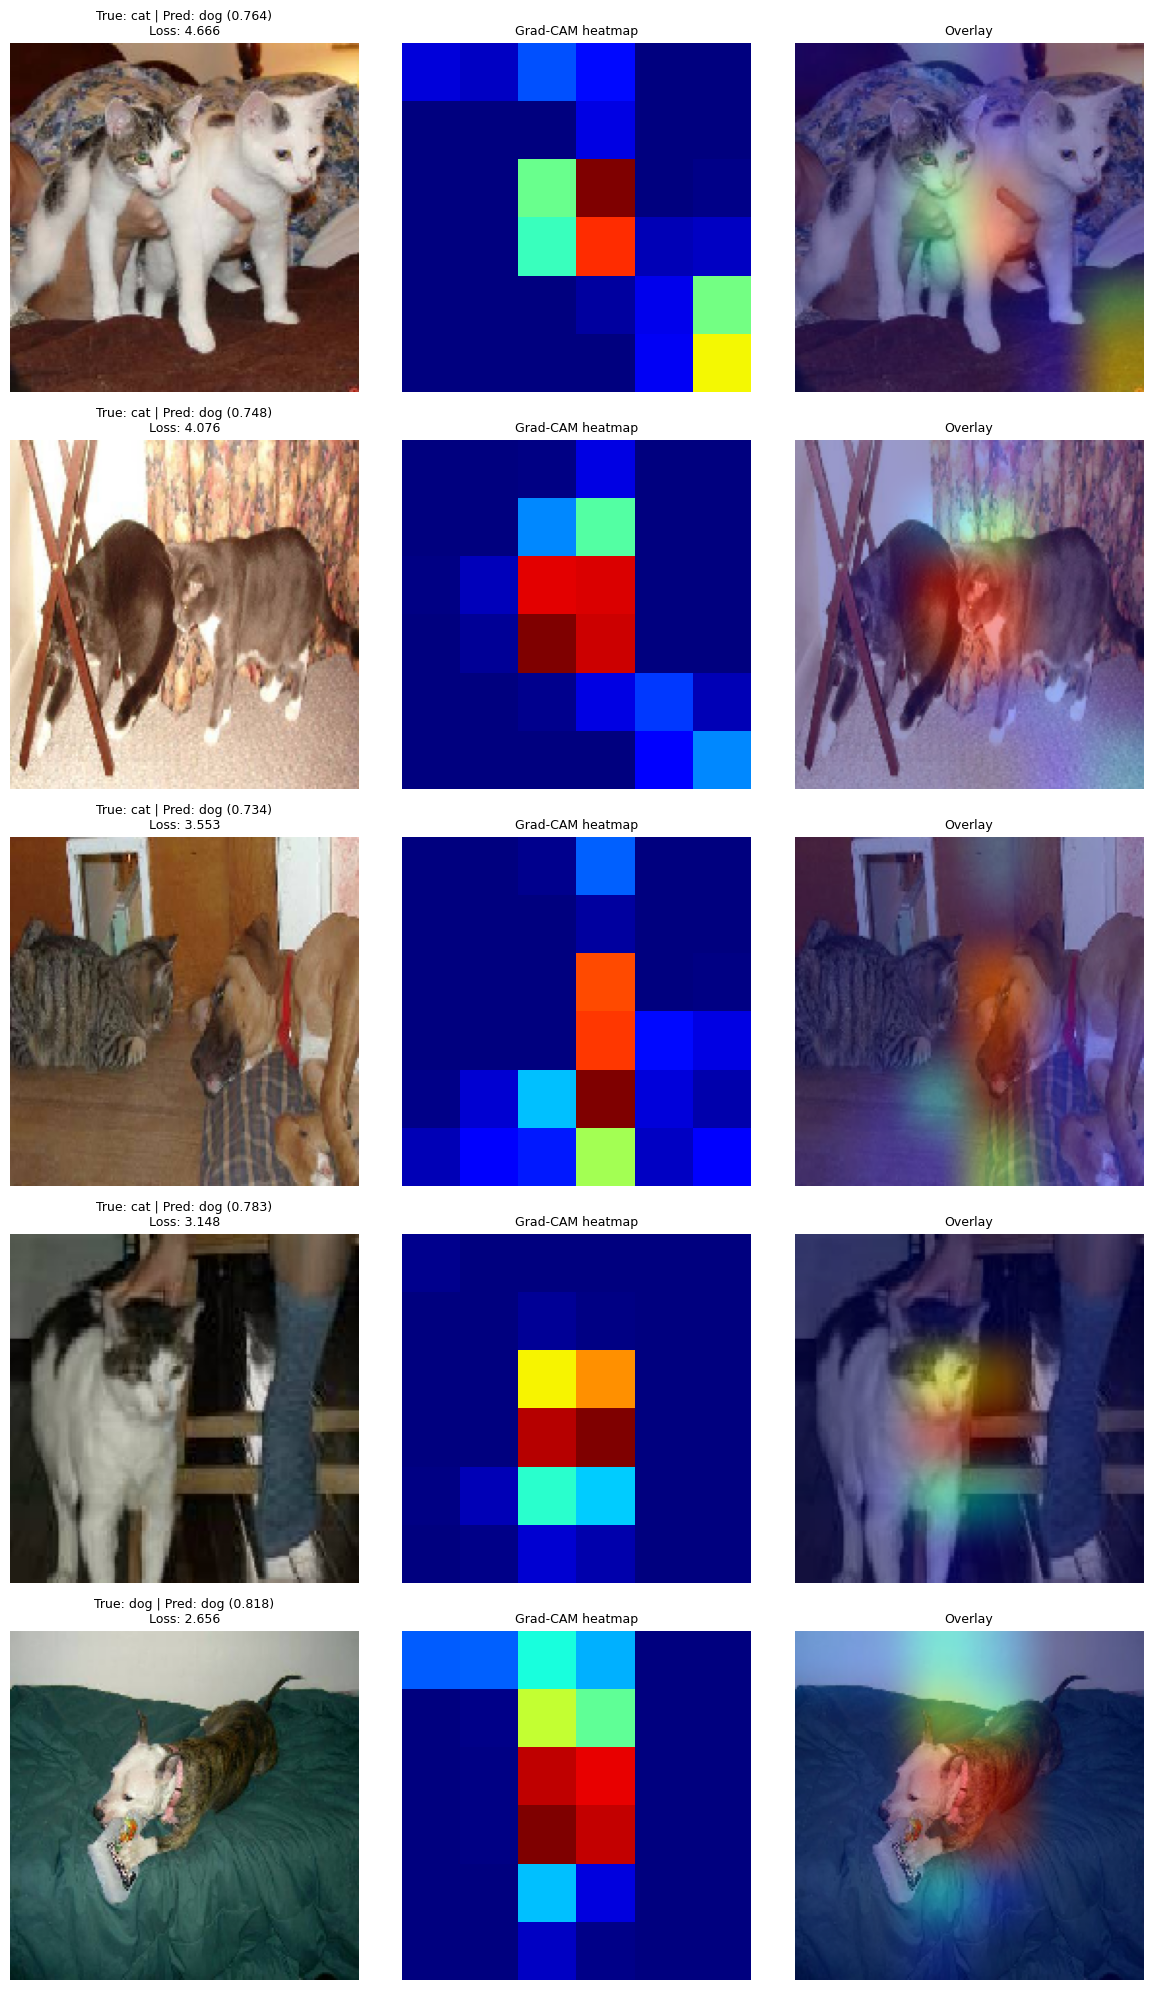

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for row, idx in enumerate(top5_idx):
    img_path = file_paths[idx]
    img_array = load_single_image(img_path)

    heatmap, pred = make_gradcam_heatmap(img_array)
    original, superimposed = overlay_gradcam(img_path, heatmap)

    true_cls = class_names[int(true_labels[idx])]
    pred_cls = "dog" if pred >= 0.5 else "cat"

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(
        f"True: {true_cls} | Pred: {pred_cls} ({pred:.3f})\n"
        f"Loss: {bce[idx]:.3f}",
        fontsize=9,
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap, cmap="jet")
    axes[row, 1].set_title("Grad-CAM heatmap", fontsize=9)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(superimposed)
    axes[row, 2].set_title("Overlay", fontsize=9)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("gradcam_top5_highest_loss_v3.png", dpi=150, bbox_inches="tight")
plt.show()